7장 시계열 예측

In [ ]:
# 예제 7.1 LSTM 파라미터 수

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense

sequence_length = 240
feature = 5

inputs = Input(shape=(sequence_length, feature))
x = LSTM(8)(inputs)
outputs = Dense(1)(x)

model = Model(inputs, outputs, name="LSTM")

model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 240, 5)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 8)                   │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 457 (1.79 KB)

 Trainable params: 457 (1.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 예제 7.2 주가 예측

# finance-datareader 설치
!pip install finance-datareader

In [2]:
# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import timeseries_dataset_from_array
import FinanceDataReader as fdr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터셋 준비
df = fdr.DataReader("005930", "2020-01-01", "2024-12-31")   # 삼성전자

In [ ]:
# 상위 데이터 출력
df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2020-01-02,55500,56000,55000,55200,12993228,-0.010753
2020-01-03,56000,56600,54900,55500,15422255,0.005435
2020-01-06,54900,55600,54600,55500,10278951,0.000000
2020-01-07,55700,56400,55600,55800,10009778,0.005405
2020-01-08,56200,57400,55900,56800,23501171,0.017921


In [ ]:
# mplfinance 설치
!pip install mplfinance

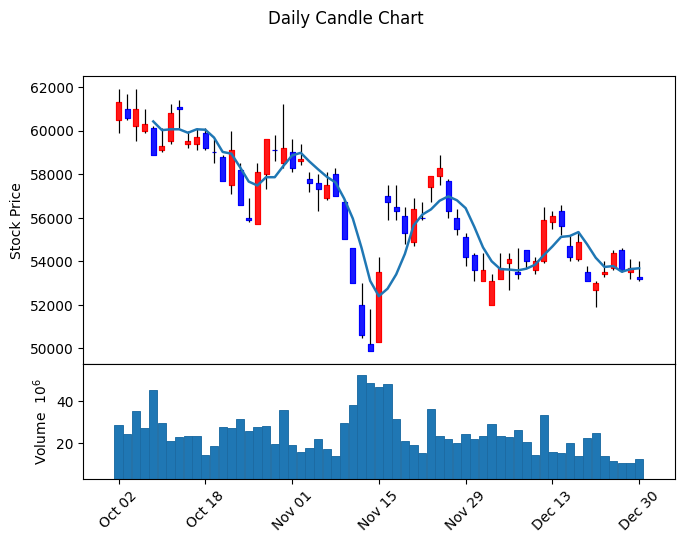

In [4]:
# 일봉 차트
import mplfinance as mpf

candle_df = df["2024-10-01":"2024-12-31"]

mc = mpf.make_marketcolors(up="red", down="blue", edge="inherit")
style = mpf.make_mpf_style(marketcolors=mc)

mpf.plot(candle_df,
         type="candle",   # 캔들 차트
         mav=(5),   # 이동 평균선
         volume=True,   # 거래량 표시
         style=style,   # 색상 지정
         figratio=(10, 7),   # 가로/세로 크기 지정
         title="Daily Candle Chart",
         ylabel="Stock Price")

In [5]:
# 불필요한 컬럼 제거
df = df.drop("Change", axis=1)

In [ ]:
# 정규화
min = df.min()
max = df.max()

stock_df = (df - min) / (max - min)

In [ ]:
# 시퀀스 데이터셋 준비
sequence_length = 3   # 3일간의 데이터 입력
offset = 1   # 다음 날 주가 예측
shift = sequence_length + offset - 1   # 레이블 위치

train_ds = timeseries_dataset_from_array(   # 학습 데이터셋
    data=stock_df["2020-01":"2022-12"].to_numpy()[:-shift],
    targets=stock_df["Close"]["2020-01":"2022-12"].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

valid_ds = timeseries_dataset_from_array(   # 검증 데이터셋
    data=stock_df["2023-01":"2023-12"].to_numpy()[:-shift],
    targets=stock_df["Close"]["2023-01":"2023-12"].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

test_ds = timeseries_dataset_from_array(   # 테스트 데이터셋
    data=stock_df["2024-01":"2024-12"].to_numpy()[:-shift],
    targets=stock_df["Close"]["2024-01":"2024-12"].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

In [ ]:
# 모델 생성
inputs = Input(shape=(sequence_length, 5))   # 입력 특징 5개
x = LSTM(8, return_sequences=True)(inputs)
x = LSTM(8)(x)
outputs = Dense(1)(x)

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [ ]:
# 모델 학습
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",   # 모니터링 지표 지정
    patience=3)   # 허용 범위 지정

history = model.fit(train_ds, epochs=50, verbose=0,
                    validation_data=valid_ds,
                    callbacks=early_stopping)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


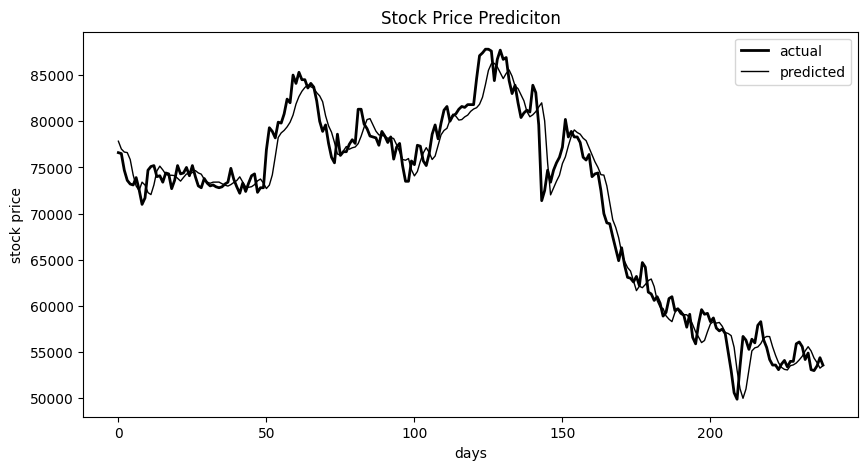

In [ ]:
# 예측 결과 시각화
max_C = df["Close"].max()   # 종가의 최대값
min_C = df["Close"].min()   # 종가의 최소값

y_pred = model.predict(test_ds)
y_pred = y_pred * (max_C - min_C) + min_C

y_test = []
for _, targets in test_ds:
    y_test.extend(targets)
y_test = np.array(y_test) * (max_C - min_C) + min_C

plt.figure(figsize=(10, 5))

plt.plot(y_test, label="actual", color="black", linewidth=2)
plt.plot(y_pred, label="predicted", color="black", linewidth=1)
plt.title("Stock Price Prediciton")
plt.xlabel("days")
plt.ylabel("stock price")
plt.legend()

plt.show()

In [ ]:
# 예제 7.3 온도 예측

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.utils import timeseries_dataset_from_array
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터셋 준비
file_paths = [
    "/content/drive/MyDrive/Datasets/SURFACE_ASOS_108_HR_2022_2022_2023.csv",
    "/content/drive/MyDrive/Datasets/SURFACE_ASOS_108_HR_2023_2023_2024.csv",
    "/content/drive/MyDrive/Datasets/SURFACE_ASOS_108_HR_2024_2024_2025.csv"
]

df_list = [pd.read_csv(path, encoding="euc-kr") for path in file_paths]
df = pd.concat(df_list, ignore_index=True)

print(df.shape)   # 데이터셋 shape 확인
print(df.columns)   # 컬럼명 확인

(26304, 27)
Index(['지점', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '풍향(16방위)', '습도(%)',
       '증기압(hPa)', '이슬점온도(°C)', '현지기압(hPa)', '해면기압(hPa)', '일조(hr)',
       '일사(MJ/m2)', '적설(cm)', '3시간신적설(cm)', '전운량(10분위)', '중하층운량(10분위)',
       '운형(운형약어)', '최저운고(100m )', '시정(10m)', '지면상태(지면상태코드)', '현상번호(국내식)',
       '지면온도(°C)', '5cm 지중온도(°C)', '10cm 지중온도(°C)', '20cm 지중온도(°C)',
       '30cm 지중온도(°C)'],
      dtype='object')


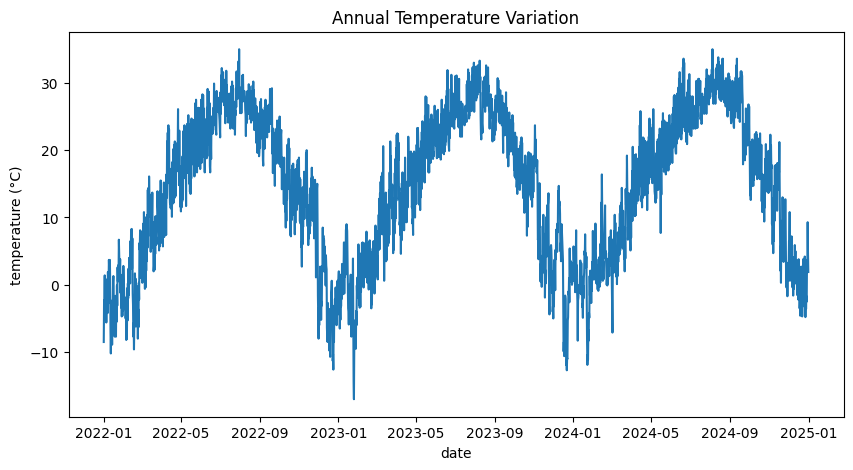

In [ ]:
# 연간 온도 변화 그래프
df['일시'] = pd.to_datetime(df["일시"])   # 날짜 형식 변환

annual_df = df.iloc[::12]   # 12시간 간격 샘플링

plt.figure(figsize=(10, 5))

plt.plot(annual_df["일시"], annual_df["기온(°C)"])
plt.title("Annual Temperature Variation")
plt.xlabel("date")
plt.ylabel("temperature (°C)")

plt.show()

In [ ]:
# 새로운 데이터셋 생성
weather_df = df[["일시", "기온(°C)", "풍속(m/s)", "풍향(16방위)",
                 "습도(%)", "현지기압(hPa)"]]

# 상위 데이터 출력
weather_df.head()

,일시,기온(°C),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa)
0,2022-01-01 00:00:00,-8.5,1.9,320.0,41,1021.9
1,2022-01-01 01:00:00,-9.2,1.8,270.0,42,1022.2
2,2022-01-01 02:00:00,-9.5,1.2,270.0,43,1022.3
3,2022-01-01 03:00:00,-9.3,1.4,290.0,46,1022.6
4,2022-01-01 04:00:00,-9.6,1.7,340.0,48,1021.9


In [ ]:
# 데이터셋 정보 확인
weather_df = weather_df.drop("일시", axis=1)   # 일시 컬럼 제거

weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   기온(°C)     26304 non-null  float64
 1   풍속(m/s)    26236 non-null  float64
 2   풍향(16방위)   26236 non-null  float64
 3   습도(%)      26304 non-null  int64  
 4   현지기압(hPa)  26304 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 1.0 MB


In [ ]:
# 결측치 있는 행 삭제
weather_df = weather_df.dropna()

In [ ]:
# 통계 요약
weather_df.describe().loc[["count", "mean", "std", "min", "max"]].round(2)

,기온(°C),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa)
count,26236.0,26236.00,26236.00,26236.00,26236.00
mean,14.1,2.32,183.09,65.63,1005.66
std,11.1,1.13,106.96,18.42,8.08
min,-17.2,0.00,0.00,14.00,981.40
max,36.3,8.80,360.00,100.00,1027.40


In [ ]:
# 정규화
min = weather_df.min()
max = weather_df.max()

weather_df = (weather_df - min) / (max - min)

In [ ]:
# 시퀀스 데이터셋 준비
num_train = int(0.8 * len(weather_df))   # 학습/검증/테스트 데이터 분할
num_valid = int(0.1 * len(weather_df))
num_test = len(weather_df) - num_train - num_valid

sequence_length = 24 * 3   # 3일간의 데이터 입력
offset = 24   # 1일 후 온도 예측
shift = sequence_length + offset - 1   # 레이블 위치

train_ds = timeseries_dataset_from_array(   # 학습 데이터셋
    data=weather_df.to_numpy()[:-shift],   # 입력
    targets=df["기온(°C)"].to_numpy()[shift:], # 레이블
    sequence_length=sequence_length,   # 시퀀스 길이
    sequence_stride=1,   # 시퀀스 스트라이드 1
    sampling_rate=1,   # 샘플 추출 간격 1
    batch_size=32,   # 배치 크기 32
    shuffle=False,   # 셔플링하지 않음
    start_index=0,   # 시퀀스 시작
    end_index=num_train)   # 시퀀스 끝

valid_ds = timeseries_dataset_from_array(   # 검증 데이터셋
    data=weather_df.to_numpy()[:-shift],
    targets=df["기온(°C)"].to_numpy()[shift:],
    sequence_length=sequence_length,
    sequence_stride=1,
    sampling_rate=1,
    batch_size=32,
    shuffle=False,
    start_index=num_train,
    end_index=num_train + num_valid)

test_ds = timeseries_dataset_from_array(   # 테스트 데이터셋
    data=weather_df.to_numpy()[:-shift],
    targets=df["기온(°C)"].to_numpy()[shift:],
    sequence_length=sequence_length,
    sequence_stride=1,
    sampling_rate=1,
    batch_size=32,
    shuffle=False,
    start_index=num_train + num_valid)

for inputs, targets in train_ds.take(1):
  print(inputs.shape)   # 입력 특징 shape 확인
  print(targets.shape)   # 레이블 shape 확인

(32, 72, 5)
(32,)


In [ ]:
# 모델 생성
inputs = Input(shape=(sequence_length, 5))   # 입력 특징 5개
x = GRU(16, return_sequences=True)(inputs)   # 뉴런 수 16개, 출력 전체 시퀀스 반환
x = GRU(16)(x)   # 뉴런 수 16개
x = Dropout(0.5)(x)   # 드롭아웃 비율 0.5
outputs = Dense(1)(x)   # 출력층 뉴런 1개

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 72, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 72, 16)         │         1,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [ ]:
# 모델 학습
history = model.fit(train_ds, epochs=20, verbose=0, validation_data=valid_ds)

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


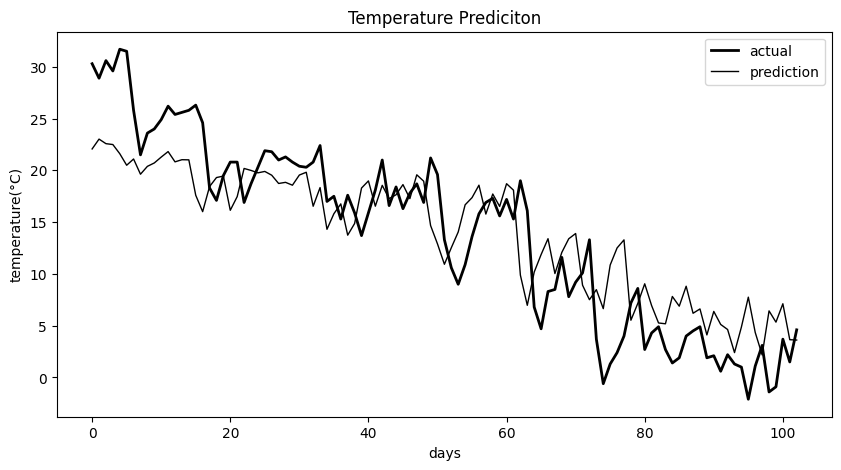

In [ ]:
# 예측 결과 시각화
y_pred = model.predict(test_ds)

y_test = []
for _, targets in test_ds:
    y_test.extend(targets)

plt.figure(figsize=(10, 5))

plt.plot(y_test[::24], label="actual", color="black", linewidth=2)   # 24시간 간격
plt.plot(y_pred[::24], label="prediction", color="black", linewidth=1)
plt.title("Temperature Prediciton")
plt.xlabel("days")
plt.ylabel("temperature(°C)")
plt.legend(loc="best")

plt.show()